<a href="https://colab.research.google.com/github/Saranraj91/-Assignment-01-Python-Data-Structures-/blob/main/Module_02_End_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# TASK 1: DATA IMPORT & SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

In [3]:
# 1. Load dataset (Assuming standard UCI Online Retail CSV format)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

In [4]:
# 2. Explore structure
print("--- Data Structure ---")
print("Head:\n", df.head())
print("\nTail:\n", df.tail())
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\nData Types & Non-Null Counts:")
df.info()

--- Data Structure ---
Head:
   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Tail:
        InvoiceNo StockCode                      Description  Quantity  \
541904    581587     22613      PACK OF 20 SPACEBOY NAPKINS        12   
54190

In [5]:
# 3. Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [6]:
# TASK 2: DATA CLEANING
print("\n--- Starting Data Cleaning ---")

# 1. Missing Values
print(f"Missing values before cleaning:\n{df.isnull().sum()}")
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 2. Duplicates
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {initial_rows - len(df_clean)} duplicate rows.")

# 3. Invalid Values (Filter out negative/zero quantity and unit price)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f"Cleaned dataset shape: {df_clean.shape}")


--- Starting Data Cleaning ---
Missing values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Removed 5225 duplicate rows.
Cleaned dataset shape: (392692, 8)


In [7]:
# TASK 3: FEATURE ENGINEERING
print("\n--- Feature Engineering ---")

# 1. Total Price
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# 2. Extract Time Features
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month_name()
df_clean['Day'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# 3. Create Custom Categories
# Order Size
df_clean['OrderSize'] = pd.cut(
    df_clean['Quantity'],
    bins=[0, 5, 20, 100, np.inf],
    labels=['Small', 'Medium', 'Large', 'Bulk']
)

# Day Type (Weekday vs Weekend)
df_clean['DayType'] = df_clean['InvoiceDate'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Customer Segment based on Total Spend
customer_spend = df_clean.groupby('CustomerID')['TotalPrice'].sum()
spend_quantiles = customer_spend.quantile([0.33, 0.66])

def segment_customer(spend):
    if spend <= spend_quantiles[0.33]:
        return 'Low-Spender'
    elif spend <= spend_quantiles[0.66]:
        return 'Mid-Spender'
    else:
        return 'High-Spender'

customer_segments = customer_spend.apply(segment_customer)
df_clean['CustomerSegment'] = df_clean['CustomerID'].map(customer_segments)


--- Feature Engineering ---


In [8]:
# TASK 4: DATA EXPLORATION
print("\n--- Exploratory Data Analysis ---")
print("Dataset Summary Statistics:")
print(df_clean.describe())

print("\nValue Counts for Customer Segment:")
print(df_clean['CustomerSegment'].value_counts())

print(f"\nUnique Products: {df_clean['Description'].nunique()}")
print(f"Unique Countries: {df_clean['Country'].nunique()}")

# Groupby Exploration
print("\nTop 5 Countries by Total Revenue:")
print(df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head())


--- Exploratory Data Analysis ---
Dataset Summary Statistics:
            Quantity                    InvoiceDate      UnitPrice  \
count  392692.000000                         392692  392692.000000   
mean       13.119702  2011-07-10 19:13:07.771892480       3.125914   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 12:02:00       1.950000   
75%        12.000000            2011-10-20 12:53:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       180.492832                            NaN      22.241836   

          CustomerID     TotalPrice           Year           Hour  
count  392692.000000  392692.000000  392692.000000  392692.000000  
mean    15287.843865      22.631500    2010.934631      12.721532  
min     12346.000000       0.001000    2010.000000       6.000000  
25%     13955.000000       4.95000

In [9]:
# TASK 5: DATA WRANGLING
print("\n--- Data Wrangling & Aggregation ---")

# Top 10 Customers by Revenue
top_customers = df_clean.groupby(['CustomerID', 'CustomerSegment'])['TotalPrice'].agg(
    TotalSpend='sum',
    OrderCount='count'
).reset_index().sort_values(by='TotalSpend', ascending=False).head(10)

print("Top 10 High-Value Customers:")
print(top_customers)

# Aggregation by Country
country_metrics = df_clean.groupby('Country').agg(
    TotalRevenue=('TotalPrice', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique'),
    AvgOrderValue=('TotalPrice', 'mean')
).sort_values(by='TotalRevenue', ascending=False)


--- Data Wrangling & Aggregation ---
Top 10 High-Value Customers:
      CustomerID CustomerSegment  TotalSpend  OrderCount
1689       14646    High-Spender   280206.02        2076
4201       18102    High-Spender   259657.30         431
3728       17450    High-Spender   194390.79         336
3008       16446    High-Spender   168472.50           3
1879       14911    High-Spender   143711.17        5670
55         12415    High-Spender   124914.53         714
1333       14156    High-Spender   117210.08        1395
3771       17511    High-Spender    91062.38         963
2702       16029    High-Spender    80850.84         241
0          12346    High-Spender    77183.60           1


In [10]:
# TASK 6: STATISTICAL ANALYSIS
print("\n--- Statistical Analysis ---")
numerical_cols = ['Quantity', 'UnitPrice', 'TotalPrice']

stats_df = pd.DataFrame(index=['Mean', 'Median', 'Mode', 'Std Dev', 'Variance', '25th Pct', '75th Pct'])

for col in numerical_cols:
    stats_df[col] = [
        df_clean[col].mean(),
        df_clean[col].median(),
        df_clean[col].mode()[0],
        df_clean[col].std(),
        df_clean[col].var(),
        df_clean[col].quantile(0.25),
        df_clean[col].quantile(0.75)
    ]

print(stats_df.round(2))


--- Statistical Analysis ---
          Quantity  UnitPrice  TotalPrice
Mean         13.12       3.13       22.63
Median        6.00       1.95       12.45
Mode          1.00       1.25       15.00
Std Dev     180.49      22.24      311.10
Variance  32577.66     494.70    96782.73
25th Pct      2.00       1.25        4.95
75th Pct     12.00       3.75       19.80


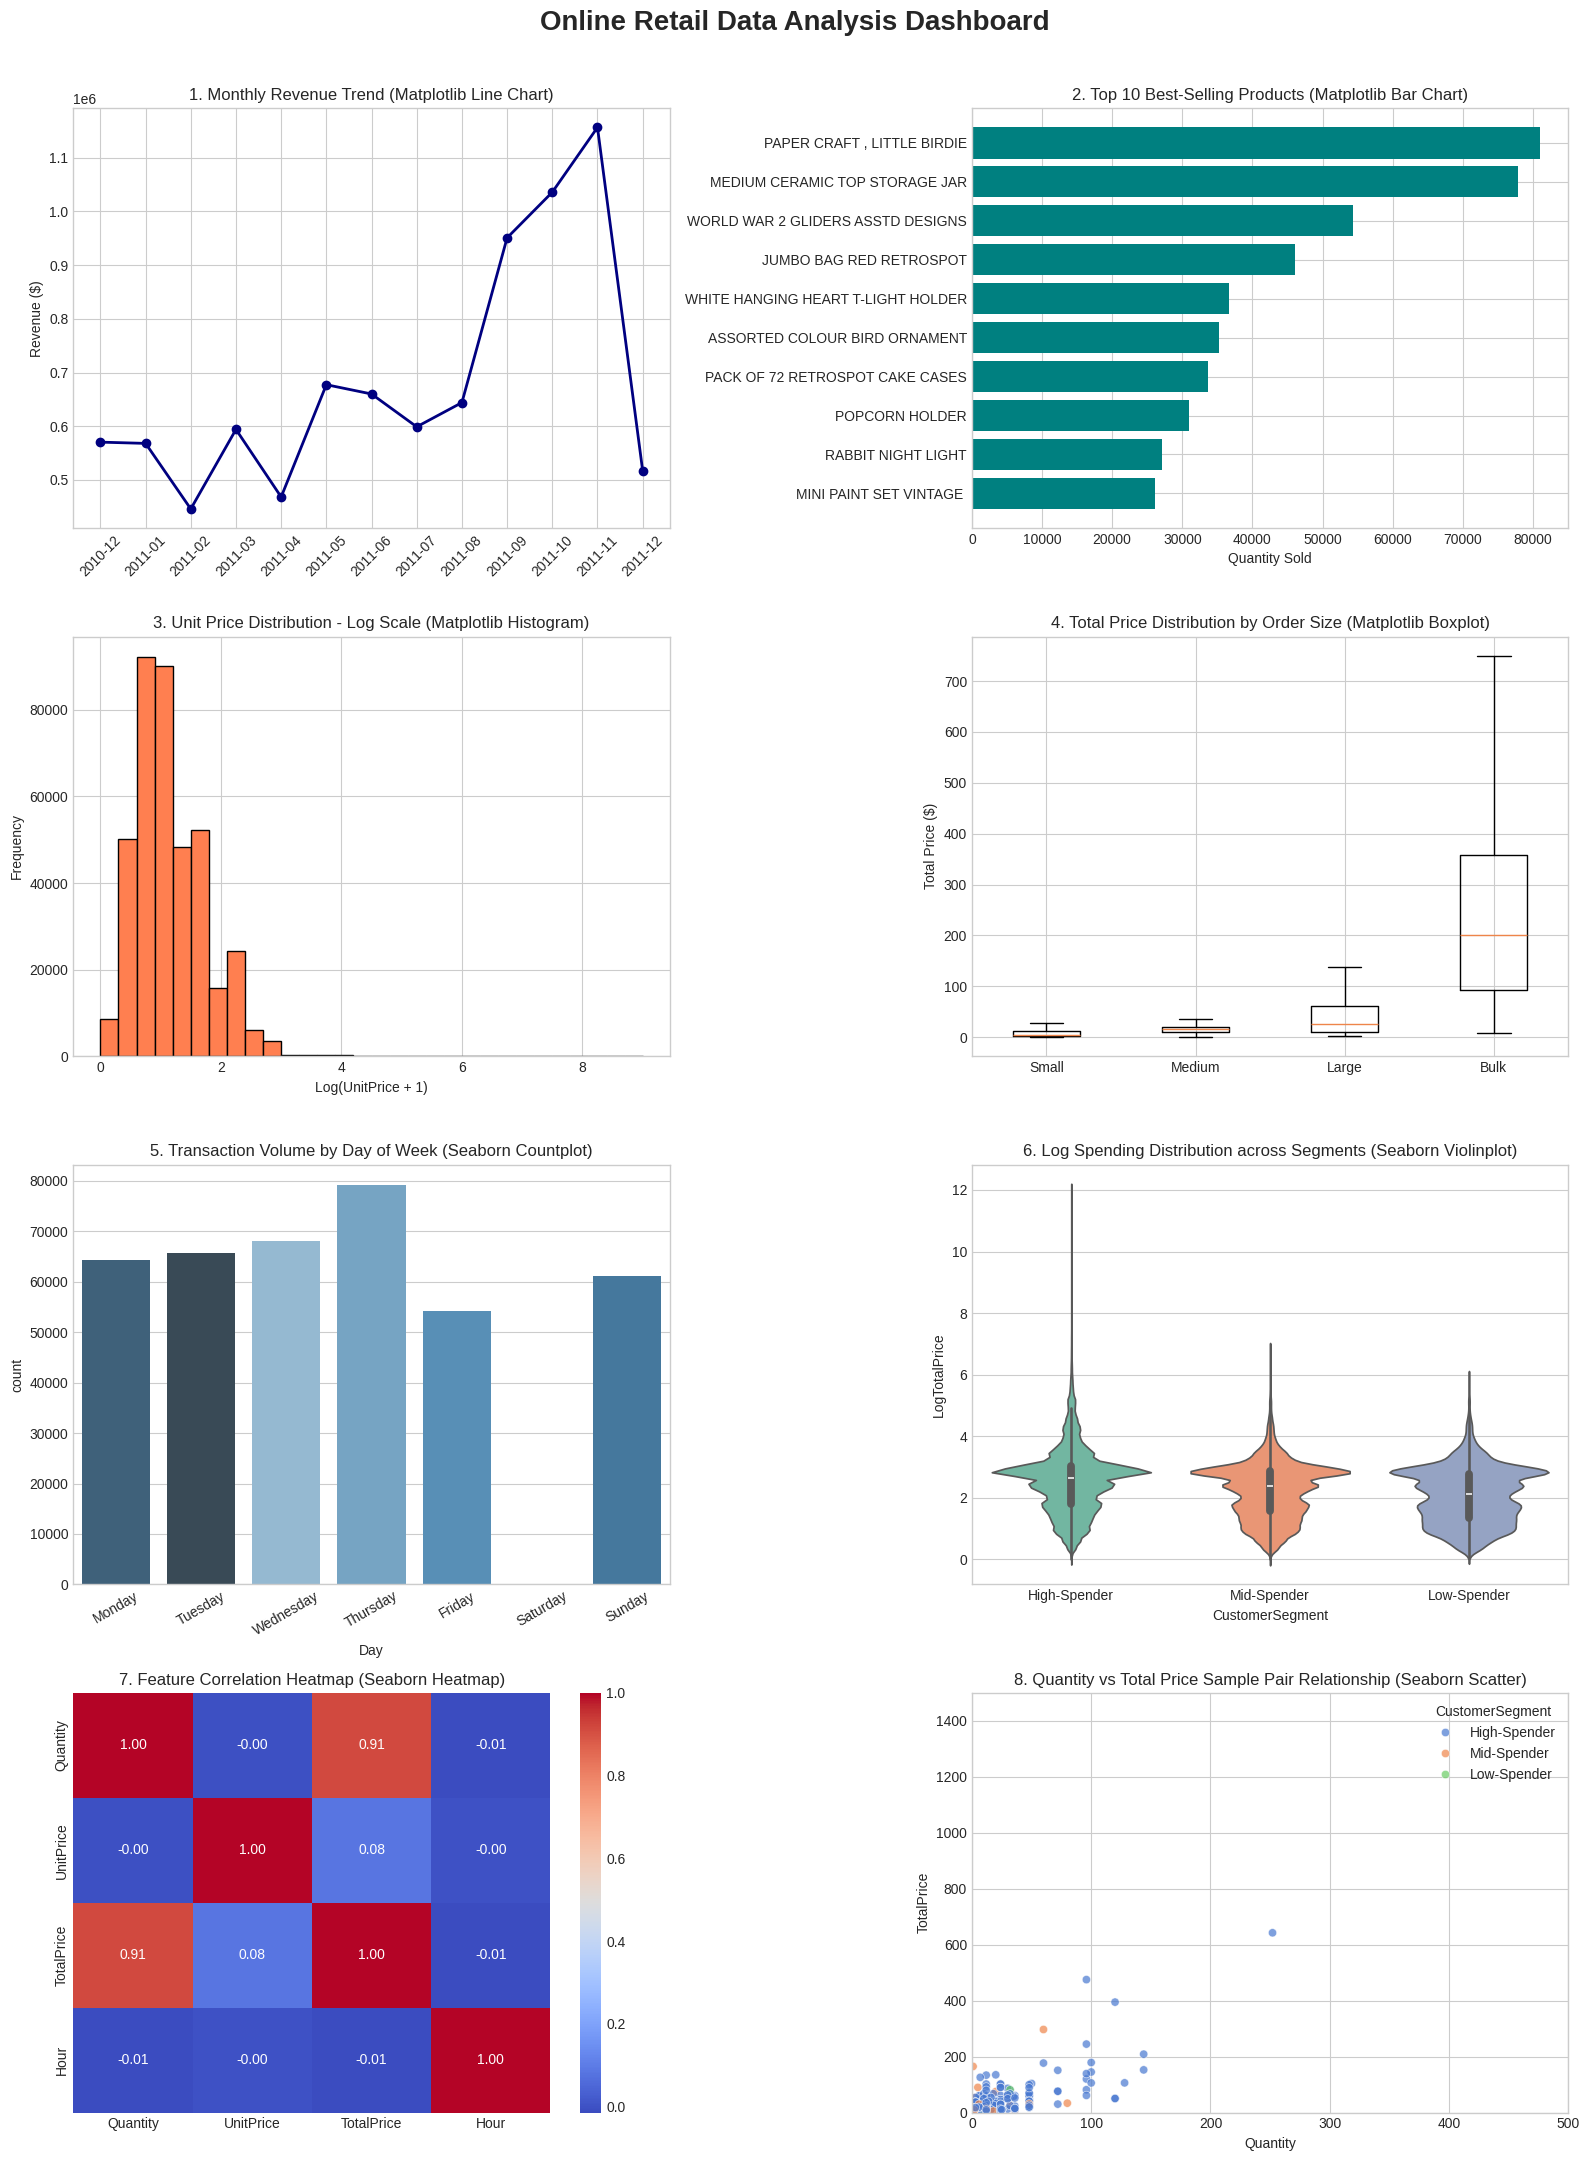

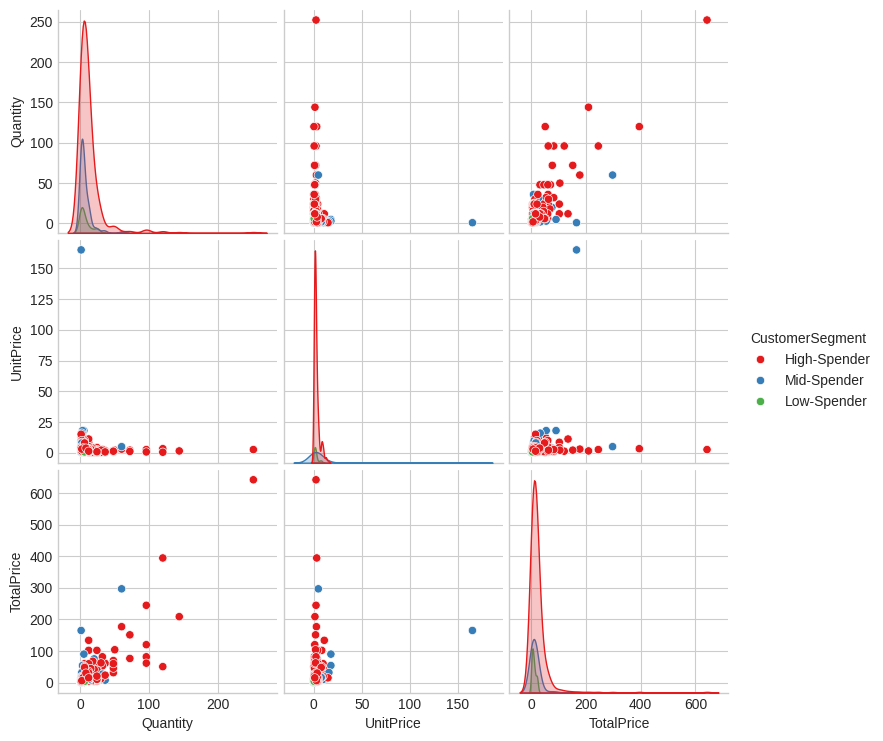

In [14]:
# TASK 7: DATA VISUALIZATION (8 PLOTS)
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
fig.suptitle('Online Retail Data Analysis Dashboard', fontsize=20, fontweight='bold', y=0.98)

# 1. Matplotlib Line Chart: Monthly Sales Trend
monthly_sales = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()
axes[0, 0].plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', color='navy', linewidth=2)
axes[0, 0].set_title('1. Monthly Revenue Trend (Matplotlib Line Chart)')
axes[0, 0].set_xticks(range(len(monthly_sales)))  # Fixed tick warning
axes[0, 0].set_xticklabels(monthly_sales.index.astype(str), rotation=45)
axes[0, 0].set_ylabel('Revenue ($)')

# 2. Matplotlib Bar Chart: Top 10 Products by Quantity Sold
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
axes[0, 1].barh(top_products.index, top_products.values, color='teal')
axes[0, 1].set_title('2. Top 10 Best-Selling Products (Matplotlib Bar Chart)')
axes[0, 1].set_xlabel('Quantity Sold')
axes[0, 1].invert_yaxis()

# 3. Matplotlib Histogram: Log Transformed Unit Price Distribution
axes[1, 0].hist(np.log1p(df_clean['UnitPrice']), bins=30, color='coral', edgecolor='black')
axes[1, 0].set_title('3. Unit Price Distribution - Log Scale (Matplotlib Histogram)')
axes[1, 0].set_xlabel('Log(UnitPrice + 1)')
axes[1, 0].set_ylabel('Frequency')

# 4. Matplotlib Box Plot: Total Spend by Order Size
order_spend_data = [group['TotalPrice'].values for name, group in df_clean.groupby('OrderSize', observed=False)]  # Fixed observed warning
axes[1, 1].boxplot(order_spend_data, tick_labels=df_clean['OrderSize'].cat.categories, showfliers=False)  # Fixed tick_labels deprecation
axes[1, 1].set_title('4. Total Price Distribution by Order Size (Matplotlib Boxplot)')
axes[1, 1].set_ylabel('Total Price ($)')

# 5. Seaborn Count Plot: Orders by Day of the Week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df_clean, x='Day', order=days_order, ax=axes[2, 0], hue='Day', palette='Blues_d', legend=False)  # Fixed hue warning
axes[2, 0].set_title('5. Transaction Volume by Day of Week (Seaborn Countplot)')
axes[2, 0].tick_params(axis='x', rotation=30)

# 6. Seaborn Violin Plot: Log Total Price across Customer Segments
df_clean['LogTotalPrice'] = np.log1p(df_clean['TotalPrice'])
sns.violinplot(data=df_clean, x='CustomerSegment', y='LogTotalPrice', ax=axes[2, 1], hue='CustomerSegment', palette='Set2', legend=False)  # Fixed hue warning
axes[2, 1].set_title('6. Log Spending Distribution across Segments (Seaborn Violinplot)')

# 7. Seaborn Heatmap: Correlation Matrix
corr_matrix = df_clean[['Quantity', 'UnitPrice', 'TotalPrice', 'Hour']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[3, 0], cbar=True)
axes[3, 0].set_title('7. Feature Correlation Heatmap (Seaborn Heatmap)')

# 8. Seaborn Pair Plot Simulation (Using Subplot Pair Scatter)
sns.scatterplot(data=df_clean.sample(1000, random_state=42), x='Quantity', y='TotalPrice', hue='CustomerSegment', ax=axes[3, 1], alpha=0.7)
axes[3, 1].set_title('8. Quantity vs Total Price Sample Pair Relationship (Seaborn Scatter)')
axes[3, 1].set_xlim(0, 500)
axes[3, 1].set_ylim(0, 1500)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('visualizations_dashboard.png')
plt.show()

# Standard Seaborn Pairplot export
sample_df = df_clean[['Quantity', 'UnitPrice', 'TotalPrice', 'CustomerSegment']].sample(500, random_state=42)
pair_plot = sns.pairplot(sample_df, hue='CustomerSegment', palette='Set1')
pair_plot.savefig('seaborn_pairplot.png')

In [15]:
# TASK 8: BUSINESS INSIGHTS
top_country = country_metrics.index[0]
best_month = monthly_sales.idxmax()
hourly_sales = df_clean.groupby('Hour')['TotalPrice'].sum()
peak_hour = hourly_sales.idxmax()

print("\n" + "="*40)
print("       EXECUTIVE BUSINESS INSIGHTS       ")
print("="*40)
print(f"1. Top Performing Country : {top_country} (Generated overwhelming majority of overall revenue)")
print(f"2. Peak Sales Month       : {best_month} (Driven by holiday retail trends)")
print(f"3. Peak Sales Hour        : {peak_hour}:00 Hours (Midday purchasing spike)")
print("4. Customer Behavior      : High-value customers drive significant revenue despite being a smaller segment.")
print("="*40)


       EXECUTIVE BUSINESS INSIGHTS       
1. Top Performing Country : United Kingdom (Generated overwhelming majority of overall revenue)
2. Peak Sales Month       : 2011-11 (Driven by holiday retail trends)
3. Peak Sales Hour        : 12:00 Hours (Midday purchasing spike)
4. Customer Behavior      : High-value customers drive significant revenue despite being a smaller segment.
